In [1]:
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
import pandas as pd

In [2]:
iris = load_iris()


In [3]:
X = iris.data
y = iris.target

In [4]:
X[10]

array([5.4, 3.7, 1.5, 0.2])

<Axes: >

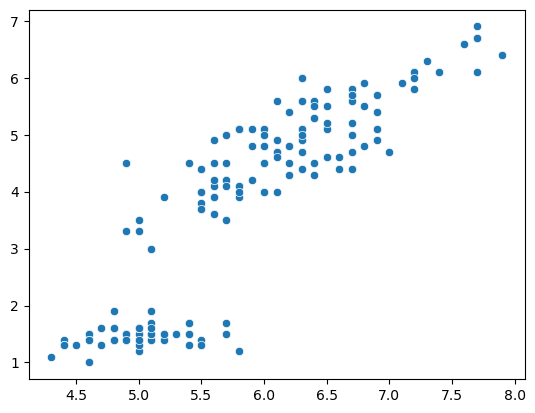

In [5]:
sns.scatterplot(x = X[: , 0] , y = X[: , 2] )

## Scale our data

In [6]:
from sklearn.preprocessing import StandardScaler

In [7]:
scale = StandardScaler()
X_scale = scale.fit_transform(X)
# Here preprocessing- Module 
# StandardScaler - Class
# scaler - instance/object of class create
# fit_transform - methods belongs to class StandardScaler

In [25]:
#X_scale 
# By scaling our data on similar scale, so our algorithim give equal importance for every feature(here 4)

### choose K value


In [9]:
wcss=[]
for k in range(1,10):
   kmeans = KMeans(n_clusters = k)
   var = kmeans.fit_predict(X_scale)
   wcss.append(kmeans.inertia_)


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, 

In [10]:
wcss

[600.0,
 222.36170496502308,
 139.8204963597498,
 114.55684421262917,
 91.63092085355163,
 82.27538988633668,
 72.5408664223387,
 62.828093442646335,
 55.4691754384866]

<Axes: >

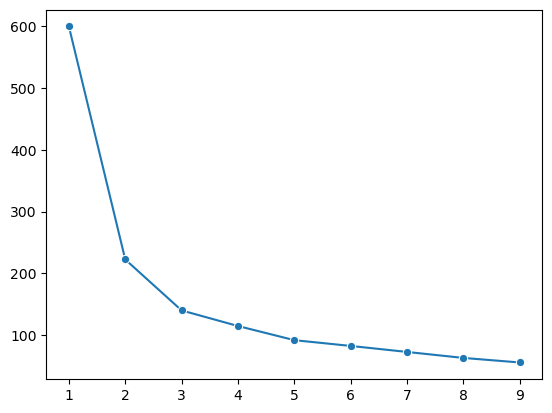

In [11]:
sns.lineplot( x = range(1,10) , y = wcss , marker = 'o')

In [12]:
!pip install kneed

In [13]:
from kneed import KneeLocator

In [14]:
knee = KneeLocator(range(1,10) , wcss , curve = "convex" , direction = "decreasing")

In [15]:
print(knee.elbow)

3


### Kmeans algo apply

In [16]:
kmeans = KMeans(n_clusters = 3 )
label  = kmeans.fit_predict(X_scale)

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [17]:
label

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 2,
       0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 2, 2, 2, 2, 2,
       2, 0, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

<Axes: >

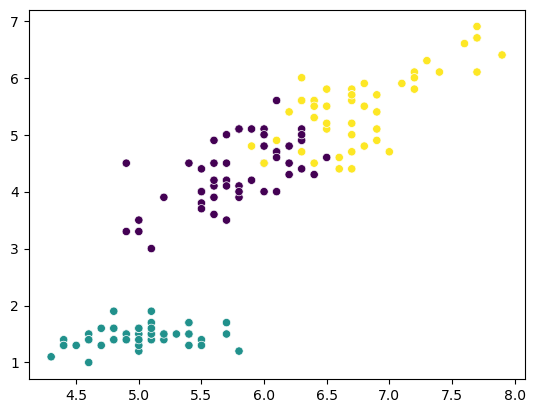

In [18]:
sns.scatterplot(x = X[: , 0] , y = X[:, 2] , c= label)

<Axes: >

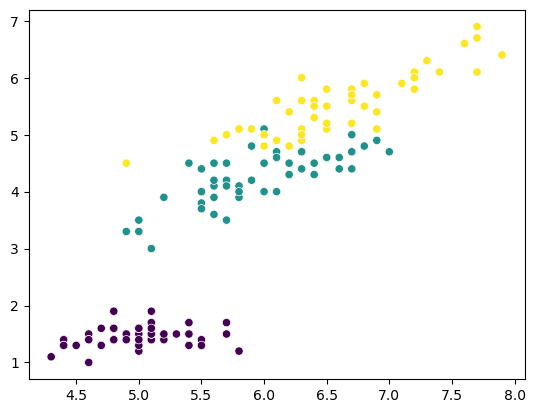

In [19]:
sns.scatterplot(x = X[: , 0] , y = X[:, 2] , c= y)

In [26]:
# 22/07/2026

### Dimensionality reduction using PCA

In [29]:
from sklearn.decomposition import PCA

pca = PCA(n_components =2)

pca_scale = pca.fit_transform(X_scale)


In [31]:
#pca_scale

In [38]:
kmeans = KMeans(n_clusters =3, random_state =10)


In [39]:
kmeans

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,10
,copy_x,True
,algorithm,'lloyd'


In [40]:
label = kmeans.fit_predict(pca_scale)

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [61]:
label.shape

(150,)

<Axes: >

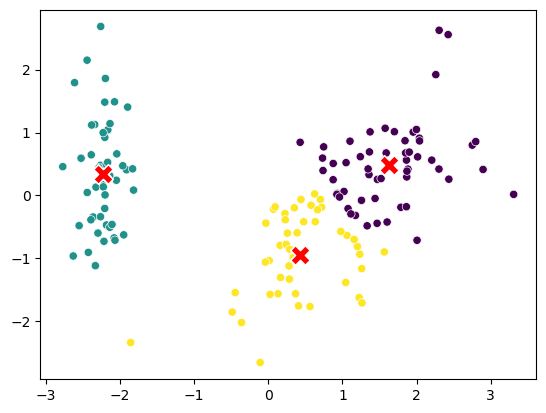

In [60]:
sns.scatterplot(x = pca_scale[:, 0] , y = pca_scale[:, 1] , c= label)
sns.scatterplot(x = kmeans.cluster_centers_[:, 0] , y = kmeans.cluster_centers_[:, 1] , marker = "X" , c = "red" , s = 200)


In [48]:
pca_scale[0: 1]

array([[-2.26470281,  0.4800266 ]])

In [55]:
pca_scale[: , 1]

array([ 0.4800266 , -0.67413356, -0.34190802, -0.59739451,  0.64683538,
        1.48917752,  0.0476442 ,  0.22314807, -1.11532768, -0.46901356,
        1.04369065,  0.13307834, -0.72867617, -0.96150673,  1.86005711,
        2.68628449,  1.48360936,  0.48883832,  1.40501879,  1.12784938,
        0.40885571,  0.92412143,  0.45834367,  0.08555853,  0.13725446,
       -0.62561859,  0.24216355,  0.52714953,  0.31321781, -0.3377319 ,
       -0.50454069,  0.42369507,  1.79357586,  2.15072788, -0.46020184,
       -0.2061074 ,  0.66155811,  0.59229277, -0.90418004,  0.26887896,
        0.44171539, -2.33741516, -0.47910069,  0.47232667,  1.14222926,
       -0.71105273,  1.1204297 , -0.38624687,  0.99795976,  0.00921636,
        0.86297242,  0.59461473,  0.61629765, -1.75440399, -0.20842105,
       -0.59328364,  0.77301931, -1.85242909,  0.03222608, -1.03401828,
       -2.65407282, -0.06329519, -1.76472438, -0.18622461, -0.43900321,
        0.50906396, -0.19631173, -0.79209574, -1.6222438 , -1.30

In [50]:
pca_scale

array([[-2.26470281,  0.4800266 ],
       [-2.08096115, -0.67413356],
       [-2.36422905, -0.34190802],
       [-2.29938422, -0.59739451],
       [-2.38984217,  0.64683538],
       [-2.07563095,  1.48917752],
       [-2.44402884,  0.0476442 ],
       [-2.23284716,  0.22314807],
       [-2.33464048, -1.11532768],
       [-2.18432817, -0.46901356],
       [-2.1663101 ,  1.04369065],
       [-2.32613087,  0.13307834],
       [-2.2184509 , -0.72867617],
       [-2.6331007 , -0.96150673],
       [-2.1987406 ,  1.86005711],
       [-2.26221453,  2.68628449],
       [-2.2075877 ,  1.48360936],
       [-2.19034951,  0.48883832],
       [-1.898572  ,  1.40501879],
       [-2.34336905,  1.12784938],
       [-1.914323  ,  0.40885571],
       [-2.20701284,  0.92412143],
       [-2.7743447 ,  0.45834367],
       [-1.81866953,  0.08555853],
       [-2.22716331,  0.13725446],
       [-1.95184633, -0.62561859],
       [-2.05115137,  0.24216355],
       [-2.16857717,  0.52714953],
       [-2.13956345,